# tamrin01 - CSM_dataset

# 1. Phase One: Preprocessing

[My source for exploring into the dataset](https://www.geeksforgeeks.org/data-analysis/exploratory-data-analysis-in-python/)

In [427]:
# reading dataset

import pandas as pd 
df = pd.read_excel('../Dataset/CSM_dataset.xlsx')
# print(df.head())
display(df)

,Movie,Year,Ratings,Genre,Gross,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers
0,13 Sins,2014,6.3,8,9130,4000000.0,45.0,1,0,3280543,4632,425,636,1120000.0
1,22 Jump Street,2014,7.1,1,192000000,50000000.0,3306.0,2,2,583289,3465,61,186,12350000.0
2,3 Days to Kill,2014,6.2,1,30700000,28000000.0,2872.0,1,0,304861,328,34,47,483000.0
3,300: Rise of an Empire,2014,6.3,1,106000000,110000000.0,3470.0,2,0,452917,2429,132,590,568000.0
4,A Haunted House 2,2014,4.7,8,17300000,3500000.0,2310.0,2,0,3145573,12163,610,1082,1923800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,Child 44,2015,6.4,4,1210000,50000000.0,66.0,1,4,3701061,9325,641,1859,NaN
227,Aloha,2015,5.5,15,21000000,37000000.0,2815.0,1,13,7119456,18803,1128,2290,NaN
228,Unfinished Business,2015,5.4,8,10200000,35000000.0,2777.0,1,7,3450614,6823,325,409,NaN
229,War Room,2015,5.4,1,12300000,3000000.0,NaN,1,10,66872,400,67,201,NaN


In [428]:
# Analyzing the data

df.shape

(231, 14)

first i want to see what i'm dealing with: using `df.info()`

In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Movie                231 non-null    object 
 1   Year                 231 non-null    int64  
 2   Ratings              231 non-null    float64
 3   Genre                231 non-null    int64  
 4   Gross                231 non-null    int64  
 5   Budget               230 non-null    float64
 6   Screens              221 non-null    float64
 7   Sequel               231 non-null    int64  
 8   Sentiment            231 non-null    int64  
 9   Views                231 non-null    int64  
 10  Likes                231 non-null    int64  
 11  Dislikes             231 non-null    int64  
 12  Comments             231 non-null    int64  
 13  Aggregate Followers  196 non-null    float64
dtypes: float64(4), int64(9), object(1)
memory usage: 25.4+ KB


- i can see that aggregate followers, budget and screens are the columns that have null rows.
- i can see the types of the columns: float, int and object(txt)
- i can see that we might don't need Movie column, because it has string in it! and we can use it in our analysis

we must think about the NAN fields because in SGD calculations `y=w*x+b` if there is just one x that is NAN, then the final result would be a NAN.

so we have two options:
1. delete the columns that has NAN fields.
2. filling the NAN fields with Mean or Median (Imputation)

In [430]:
df.drop(columns=["Movie"], axis=1, inplace=True)

In [431]:
df.corr().round(2)

,Year,Ratings,Genre,Gross,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers
Year,1.00,-0.00,-0.03,0.12,0.10,0.25,0.10,0.23,0.21,0.08,0.23,0.04,-0.04
Ratings,-0.00,1.00,-0.12,0.34,0.29,0.06,0.11,0.14,0.01,0.07,-0.19,0.02,0.08
Genre,-0.03,-0.12,1.00,-0.20,-0.26,-0.15,-0.22,-0.01,-0.03,-0.04,-0.03,-0.10,0.01
Gross,0.12,0.34,-0.20,1.00,0.72,0.59,0.42,-0.02,0.18,0.11,0.16,0.13,0.30
Budget,0.10,0.29,-0.26,0.72,1.00,0.60,0.46,0.03,0.11,0.01,0.10,0.09,0.17
Screens,0.25,0.06,-0.15,0.59,0.60,1.00,0.27,-0.02,0.26,0.17,0.27,0.21,0.21
Sequel,0.10,0.11,-0.22,0.42,0.46,0.27,1.00,-0.11,-0.04,-0.04,-0.06,-0.07,0.23
Sentiment,0.23,0.14,-0.01,-0.02,0.03,-0.02,-0.11,1.00,0.06,0.05,0.04,0.06,-0.09
Views,0.21,0.01,-0.03,0.18,0.11,0.26,-0.04,0.06,1.00,0.68,0.78,0.71,0.16
Likes,0.08,0.07,-0.04,0.11,0.01,0.17,-0.04,0.05,0.68,1.00,0.47,0.92,0.08


In [432]:
import numpy as np

corr = df.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_corr = (
    upper.stack()
         .sort_values(key=abs, ascending=False).round(2)
)

top_corr.head(10)

Likes     Comments    0.92
Views     Dislikes    0.78
Gross     Budget      0.72
Views     Comments    0.71
          Likes       0.68
Budget    Screens     0.60
Gross     Screens     0.59
Dislikes  Comments    0.58
Likes     Dislikes    0.47
Budget    Sequel      0.46
dtype: float64

likes, comments, views and dislikes have a massive relationship together.

In [433]:
top_corr.tail(10)

Genre    Dislikes              -0.03
Year     Genre                 -0.03
Gross    Sentiment             -0.02
Screens  Sentiment             -0.02
Ratings  Comments               0.02
         Views                  0.01
Budget   Likes                  0.01
Genre    Sentiment             -0.01
         Aggregate Followers    0.01
Year     Ratings               -0.00
dtype: float64

In [434]:
gross_corr = df.corr()['Gross'].sort_values(ascending=False)
print(gross_corr)


Gross                  1.000000
Budget                 0.719839
Screens                0.586447
Sequel                 0.423711
Ratings                0.342204
Aggregate Followers    0.301808
Views                  0.176363
Dislikes               0.161536
Comments               0.125960
Year                   0.122672
Likes                  0.110432
Sentiment             -0.017100
Genre                 -0.197009
Name: Gross, dtype: float64


- high correlation like budget are the prime candidates for our model.
- Near zero correlations may have a nonlinear relationship

<Axes: >

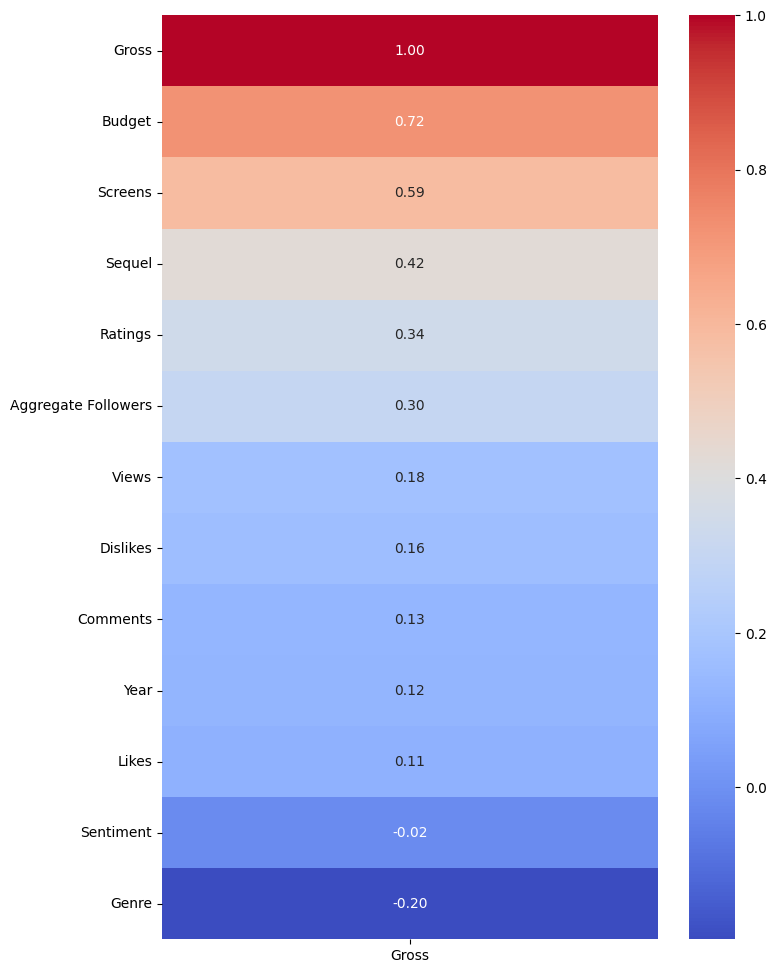

In [435]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 12))
sns.heatmap(df.corr()[['Gross']].sort_values(by='Gross', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")

- we can see budget, screens and sequel are the main pillars.
- but it seems that likes, comments, views and dislikes don't have a good relation with the budget at the first sight.

In [436]:
df.columns.tolist()

['Year',
 'Ratings',
 'Genre',
 'Gross',
 'Budget',
 'Screens',
 'Sequel',
 'Sentiment',
 'Views',
 'Likes',
 'Dislikes',
 'Comments',
 'Aggregate Followers']

In [437]:
# Checking missing values
df.isnull().sum()

Year                    0
Ratings                 0
Genre                   0
Gross                   0
Budget                  1
Screens                10
Sequel                  0
Sentiment               0
Views                   0
Likes                   0
Dislikes                0
Comments                0
Aggregate Followers    35
dtype: int64

Now i just want to complete the fields that are empty in screens and budget.
(aggregate followers are not as important as they are!)

In [438]:
screen_corr = df.corr()['Screens'].sort_values(ascending=False)
print(screen_corr)

Screens                1.000000
Budget                 0.595684
Gross                  0.586447
Dislikes               0.268176
Sequel                 0.267456
Views                  0.256515
Year                   0.251472
Comments               0.213039
Aggregate Followers    0.210822
Likes                  0.173473
Ratings                0.057625
Sentiment             -0.017046
Genre                 -0.145807
Name: Screens, dtype: float64


In [439]:
budget_corr = df.corr()['Budget'].sort_values(ascending=False)
print(budget_corr)

Budget                 1.000000
Gross                  0.719839
Screens                0.595684
Sequel                 0.464733
Ratings                0.288157
Aggregate Followers    0.168874
Views                  0.114708
Year                   0.098516
Dislikes               0.096888
Comments               0.090559
Sentiment              0.033616
Likes                  0.011701
Genre                 -0.264286
Name: Budget, dtype: float64


In [440]:
missing_cols = ['Budget', 'Screens']
print(df.corr()[missing_cols].sort_values(by='Budget', ascending=False))

                       Budget   Screens
Budget               1.000000  0.595684
Gross                0.719839  0.586447
Screens              0.595684  1.000000
Sequel               0.464733  0.267456
Ratings              0.288157  0.057625
Aggregate Followers  0.168874  0.210822
Views                0.114708  0.256515
Year                 0.098516  0.251472
Dislikes             0.096888  0.268176
Comments             0.090559  0.213039
Sentiment            0.033616 -0.017046
Likes                0.011701  0.173473
Genre               -0.264286 -0.145807


at first we want to see how the model works with just the three pillars: 
- budget
- screens
- sequel

but we have to first fill the nan fields in these three.

In [441]:
# Checking missing values
df.isnull().sum()

Year                    0
Ratings                 0
Genre                   0
Gross                   0
Budget                  1
Screens                10
Sequel                  0
Sentiment               0
Views                   0
Likes                   0
Dislikes                0
Comments                0
Aggregate Followers    35
dtype: int64

- i don't want to complete the fields with the median or mean of the entire fields that it has.
- and i don't want to use the other selected columns (Gross, Budget, Screens and Sequel), because it effect on the independence of the selected columns.
- so what were going to do is to use `KNN IMPUTER` and we use the unselected features to filled the NAN fields.

In [442]:
from sklearn.impute import KNNImputer
import pandas as pd

imputer = KNNImputer(n_neighbors=5)

features_for_budget = df.drop(columns=['Screens', 'Gross'])
df_budget_imputed = pd.DataFrame(imputer.fit_transform(features_for_budget), columns=features_for_budget.columns)
df['Budget'] = df_budget_imputed['Budget']

features_for_screens = df.drop(columns=['Budget', 'Gross'])
df_screens_imputed = pd.DataFrame(imputer.fit_transform(features_for_screens), columns=features_for_screens.columns)
df['Screens'] = df_screens_imputed['Screens']

In [443]:
df.isnull().sum()

Year                    0
Ratings                 0
Genre                   0
Gross                   0
Budget                  0
Screens                 0
Sequel                  0
Sentiment               0
Views                   0
Likes                   0
Dislikes                0
Comments                0
Aggregate Followers    35
dtype: int64

In [444]:
df.drop(columns=['Year',
 'Ratings',
 'Genre',
 'Sentiment',
 'Views',
 'Likes',
 'Dislikes',
 'Comments',
 'Aggregate Followers'], axis=1, inplace=True)

In [445]:
df.isnull().sum()

Gross      0
Budget     0
Screens    0
Sequel     0
dtype: int64

In [446]:
df.head()

,Gross,Budget,Screens,Sequel
0,9130,4000000.0,45.0,1
1,192000000,50000000.0,3306.0,2
2,30700000,28000000.0,2872.0,1
3,106000000,110000000.0,3470.0,2
4,17300000,3500000.0,2310.0,2


we have to think about the huge number for 'Gross', 'Budget', 'Screens' that makes the difference between numbers massively!
so we use log1p from numpy.

In [447]:
df[['Gross', 'Budget', 'Screens']] = np.log1p(df[['Gross', 'Budget', 'Screens']])

In [448]:
# https://www.geeksforgeeks.org/python/select-all-columns-except-one-given-column-in-a-pandas-dataframe/
X = df.loc[ : , df.columns != 'Gross']
X.head()

,Budget,Screens,Sequel
0,15.201805,3.828641,1
1,17.727534,8.103797,2
2,17.147715,7.963112,1
3,18.515991,8.152198,2
4,15.068274,7.745436,2


In [449]:
y = df['Gross']
y.head()

0     9.119430
1    19.073006
2    17.239773
3    18.478950
4    16.666217
Name: Gross, dtype: float64

In [450]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:\n", X_train)
print("\nX_test:\n", X_test)

X_train:
         Budget   Screens  Sequel
55   18.921456  8.178077       1
229  14.914123  7.581210       1
69   17.504390  8.062748       1
168  17.182806  8.153062       2
109  16.066802  7.369601       1
..         ...       ...     ...
106  16.811243  8.150756       1
14   15.424949  4.189655       3
92   18.450240  8.281218       2
179  19.062535  8.287277       1
102  16.906553  8.089789       1

[184 rows x 3 columns]

X_test:
         Budget   Screens  Sequel
218  17.216708  7.927685       1
66   16.648724  7.336286       1
9    16.341239  7.720462       1
170  18.720785  8.218518       1
15   15.607270  2.944439       1
200  16.300417  8.016978       1
25   14.914123  5.948035       1
196  17.370859  8.007700       1
154  16.523561  6.678342       1
126  16.906553  7.612831       1
215  15.201805  2.708050       1
19   16.012735  7.508787       1
96   17.370859  7.818832       1
178  17.370859  8.058011       1
175  17.147715  7.922261       1
137  16.523561  7.929126       1

In [451]:
print("\ny_train:\n", y_train)
print("")
print("\ny_test:\n", y_test)


y_train:
 55     19.051953
229    16.325110
69     18.659698
168    19.024997
109    14.767169
         ...    
106    18.252262
14     13.629182
92     18.698312
179    18.350258
102    17.904843
Name: Gross, Length: 184, dtype: float64


y_test:
 218    17.717483
66     18.227096
9      17.699134
170    18.991660
15      9.375940
200    17.262318
25     15.667110
196    17.356470
154    17.220036
126    17.808191
215    11.767575
19     16.888204
96     16.166886
178    18.469471
175    18.720785
137    17.034386
146    15.248212
30     18.832790
226    14.006132
185    18.003649
108    17.073607
162    13.482833
205    16.594330
181    18.308631
125    14.703402
18     19.218188
147    17.092655
101    16.440179
104    17.601970
84     10.482934
198    17.321068
60     17.665658
118    17.486735
45     18.939475
16     11.188593
127    19.635593
159    10.021315
119    18.643824
82     18.430631
144     8.517393
93     17.886245
194    17.401803
143    13.919871
73     16.157316
11

In [452]:
# https://www.geeksforgeeks.org/python/how-to-scale-pandas-dataframe-columns/
# Min-Max Normalization
X_train_norm = (X_train-X_train.min())/(X_train.max()-X_train.min())
print("Scaled Dataset Using Pandas")
X_train_norm.head()

Scaled Dataset Using Pandas


,Budget,Screens,Sequel
55,0.949208,0.973316,0.000000
229,0.459356,0.891256,0.000000
69,0.775987,0.957460,0.000000
168,0.736677,0.969876,0.166667
109,0.600258,0.862163,0.000000


# 2. Phase two: The Model and Gradient descent

In [453]:
X_train_with_ones = np.hstack((np.ones((X_train_norm.shape[0], 1)), X_train_norm))
theta_matrix = np.zeros((X_train_with_ones.shape[1],1))
print(X_train_with_ones.shape)
print(theta_matrix.shape)
prediction_matrix =X_train_with_ones@theta_matrix
def compute_cost(y_true, y_pred)->float:
    return (1/(2*y_pred.shape[0]))* (np.sum((y_true-y_pred)**2))

alpha = 0.01
def gradient_descent(X,y_true, alpha, theta,prediction)-> np.ndarray:
    return theta - (alpha/(X.shape[0]))* (X.T @ (prediction-y_true))
y_train = y_train.to_numpy().reshape(-1, 1)
print(y_train.shape)
for i in range(1000):
    prediction_matrix =X_train_with_ones@theta_matrix
    if i%100 ==0:
        print(i,": ",compute_cost(y_train,prediction_matrix))
    theta_matrix = gradient_descent(X_train_with_ones,y_train, alpha, theta_matrix,prediction_matrix)

(184, 4)
(4, 1)
(184, 1)
0 :  143.08189768596694
100 :  3.3088834052573617
200 :  1.6355245652644061
300 :  1.6012772174186385
400 :  1.587486157434032
500 :  1.5748792894794839
600 :  1.5631603482776435
700 :  1.5522630860995101
800 :  1.5421285608700352
900 :  1.532702156457415


Now i want to use regularization instead of the simple cost function to decrease the cost

In [454]:
def compute_cost_reg(y_true, y_pred, theta, lambda_)->float:
    m = y_pred.shape[0]
    mse_term = np.sum((y_true - y_pred)**2)
    reg_term = lambda_ * np.sum(theta[1:]**2) # not bias!
    return (1/(2*m)) * (mse_term + reg_term)

In [455]:
def gradient_descent_with_reg(X, y_true, alpha, theta, prediction, lambda_)-> np.ndarray:
    m = X.shape[0]
    grad = (1/m) * (X.T @ (prediction - y_true))
    reg = (lambda_ / m) * theta
    reg[0] = 0 # not bias!
    grad = grad + reg
    return theta - alpha * grad

In [456]:
lambda_ = 1.0
theta_matrix_reg = np.zeros((X_train_with_ones.shape[1],1))
for i in range(1000):
    prediction_matrix = X_train_with_ones @ theta_matrix_reg
    if i % 100 == 0:
        print(i, ": ", compute_cost_reg(y_train, prediction_matrix, theta_matrix_reg, lambda_))
    theta_matrix_reg = gradient_descent_with_reg(
        X_train_with_ones, y_train, alpha, theta_matrix_reg, prediction_matrix, lambda_
    )


0 :  143.08189768596694
100 :  3.484803191581459
200 :  1.8174768466123015
300 :  1.7778254691262105
400 :  1.7589344262095565
500 :  1.7417362547123945
600 :  1.7258915437115476
700 :  1.7112907855185666
800 :  1.6978355817739752
900 :  1.6854353920811924


I've tested with lambda 1,2,3,4,5 and it does get worse! the best one was 1.

this is for seeing what the parameters with normal equation

In [457]:
theta_normal_equation = np.linalg.solve(X_train_with_ones.T @ X_train_with_ones, X_train_with_ones.T @ y_train)

print(theta_normal_equation)

[[9.3556341 ]
 [6.63213321]
 [3.27103438]
 [1.07925815]]


first i use my gradient descent function

In [458]:
X_test_norm = (X_test - X_train.min()) / (X_train.max() - X_train.min())
X_test_with_ones = np.hstack((np.ones((X_test_norm.shape[0], 1)), X_test_norm))
# print(X_train_with_ones.shape)
# print(theta_matrix.shape)
y_pred  =X_test_with_ones@theta_matrix

y_test = y_test.to_numpy().reshape(-1, 1)
# print(X_test.shape)
print(compute_cost(y_test,y_pred ))

2.179681991878597


now check with regularization function:

In [459]:
lambda_ = 1.0

y_pred  =X_test_with_ones@theta_matrix_reg
print(compute_cost_reg(y_test,y_pred, theta_matrix_reg,lambda_))

2.8031130990583994


then i check with normal equation

In [460]:
y_pred_normal_equation = X_test_with_ones @ theta_normal_equation
print(compute_cost(y_test,y_pred_normal_equation ))

2.080497938043268


the comparison of the real and predicted data we reached with our gradient descent

In [461]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Actual': y_test.flatten(),
    'Predicted': y_pred.flatten()
})

print(comparison_df.head(15))


       Actual  Predicted
0   17.717483  17.539055
1   18.227096  16.716673
2   17.699134  16.792418
3   18.991660  18.773587
4    9.375940  12.762445
5   17.262318  16.984063
6   15.667110  14.514211
7   17.356470  17.702716
8   17.220036  16.145203
9   17.808191  17.095964
10  11.767575  12.312791
11  16.888204  16.413205
12  16.166886  17.563023
13  18.469471  17.739928
14  18.720785  17.488282


In [462]:
mse = np.mean((y_test.flatten() - y_pred.flatten())**2)
print("MSE:", mse)


MSE: 4.327867636155209


In [463]:
import math
print("RMSE:",math.sqrt(mse))

RMSE: 2.0803527672380975


In [464]:
ss_res = np.sum((y_test.flatten() - y_pred.flatten())**2)
ss_tot = np.sum((y_test.flatten() - np.mean(y_test.flatten()))**2)
r2_score = 1 - (ss_res / ss_tot)
print("R^2 Score:", r2_score)


R^2 Score: 0.42754362271085233


it seems that it could learn 42 percent of the pattern and the data changes
- this is very low and it shows that maybe i did a too much filtering in data or because of the lack of data i reached to this point.
- but in my point of view the separation the data was necessary (the reasons i was said in the markdown between codes)

# 3. The answer to the question of the tamrin 1


- Can we delete the movie name from the dataset for preprocessing? why?
in my opinion, Yes we can. we can delete the film names because our dataset is numeric and we selected regression model to calculate the prediction. we need numeric numbers for the model not strings! and the name of the movie since we use calculation with just gradient descent seems not enough for that and the meaning of the words and the level of impact on the audience may have some numeric results that we do not use it yet!

### Polynomial Regression
now i want to test it with **2,3,4 and 5 of each features that i've selected

In [465]:
def make_polynomial(X, degree):
    X_poly = X.copy()
    for d in range(2, degree + 1):
        X_poly[f"x^{d}"] = X.iloc[:, 0] ** d
    return X_poly

def minmax_normalize(X, X_min, X_max):
    return (X - X_min) / (X_max - X_min)

def add_bias(X):
    return np.hstack((np.ones((X.shape[0], 1)), X))

def compute_cost(y_true, y_pred):
    return (1 / (2 * y_pred.shape[0])) * np.sum((y_true - y_pred) ** 2)

def gradient_descent(X, y_true, alpha, theta, prediction):
    return theta - (alpha / X.shape[0]) * (X.T @ (prediction - y_true))

In [466]:
degrees = [1, 2, 3, 4, 5]
alpha = 0.01
iterations = 1000

for d in degrees:
    X_train_poly = make_polynomial(X_train, d)
    
    X_min = X_train_poly.min()
    X_max = X_train_poly.max()
    
    X_train_poly_norm = minmax_normalize(X_train_poly, X_min, X_max)
    X_train_mat = add_bias(X_train_poly_norm.values)
    
    theta = np.zeros((X_train_mat.shape[1], 1))
    
    for i in range(iterations):
        prediction = X_train_mat @ theta
        theta = gradient_descent(X_train_mat, y_train, alpha, theta, prediction)
    
    pred_train = X_train_mat @ theta
    train_error = compute_cost(y_train, pred_train)
    
    X_test_poly = make_polynomial(X_test, d)
    X_test_poly_norm = minmax_normalize(X_test_poly, X_min, X_max)
    X_test_mat = add_bias(X_test_poly_norm.values)
    
    pred_test = X_test_mat @ theta
    test_error = compute_cost(y_test, pred_test)
    
    print(f"d={d} → train: {train_error:.4f}, MSE_train: {train_error*2:.4f}, RMSE_test: {math.sqrt(train_error*2):.4f} , test: {test_error:.4f}, MSE_test: {test_error*2:.4f}, RMSE_test: {math.sqrt(test_error*2):.4f}")


d=1 → train: 1.5239, MSE_train: 3.0479, RMSE_test: 1.7458 , test: 2.1797, MSE_test: 4.3594, RMSE_test: 2.0879
d=2 → train: 1.5591, MSE_train: 3.1182, RMSE_test: 1.7658 , test: 2.1777, MSE_test: 4.3553, RMSE_test: 2.0869
d=3 → train: 1.6546, MSE_train: 3.3093, RMSE_test: 1.8191 , test: 2.2791, MSE_test: 4.5581, RMSE_test: 2.1350
d=4 → train: 1.7267, MSE_train: 3.4533, RMSE_test: 1.8583 , test: 2.3661, MSE_test: 4.7322, RMSE_test: 2.1754
d=5 → train: 1.7600, MSE_train: 3.5200, RMSE_test: 1.8762 , test: 2.4137, MSE_test: 4.8274, RMSE_test: 2.1971


well we can see that it doesn't do any better in this senario
- but it is very good in train data!
- we have overfitting!

# 4. second approach

for better preprocessing i don't remove any features and use _mod, _mean and the sentimental_analysis for movies names.(i want to be creative!)


In [467]:
import math
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [468]:
raw_data = pd.read_excel('../Dataset/CSM_dataset.xlsx')
raw_data

,Movie,Year,Ratings,Genre,Gross,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers
0,13 Sins,2014,6.3,8,9130,4000000.0,45.0,1,0,3280543,4632,425,636,1120000.0
1,22 Jump Street,2014,7.1,1,192000000,50000000.0,3306.0,2,2,583289,3465,61,186,12350000.0
2,3 Days to Kill,2014,6.2,1,30700000,28000000.0,2872.0,1,0,304861,328,34,47,483000.0
3,300: Rise of an Empire,2014,6.3,1,106000000,110000000.0,3470.0,2,0,452917,2429,132,590,568000.0
4,A Haunted House 2,2014,4.7,8,17300000,3500000.0,2310.0,2,0,3145573,12163,610,1082,1923800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,Child 44,2015,6.4,4,1210000,50000000.0,66.0,1,4,3701061,9325,641,1859,NaN
227,Aloha,2015,5.5,15,21000000,37000000.0,2815.0,1,13,7119456,18803,1128,2290,NaN
228,Unfinished Business,2015,5.4,8,10200000,35000000.0,2777.0,1,7,3450614,6823,325,409,NaN
229,War Room,2015,5.4,1,12300000,3000000.0,NaN,1,10,66872,400,67,201,NaN


In [469]:
Y = raw_data.pop('Gross')
X = raw_data

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(184, 13) (47, 13) (184,) (47,)


In [470]:
X_train.isna().sum()

Movie                   0
Year                    0
Ratings                 0
Genre                   0
Budget                  1
Screens                 4
Sequel                  0
Sentiment               0
Views                   0
Likes                   0
Dislikes                0
Comments                0
Aggregate Followers    27
dtype: int64

In [471]:
missing_cols = X_train.columns[X_train.isna().any()].tolist()
cont_attr = []
cont_attr.extend(missing_cols)
dis_attr = ['Movie']

i use a indicator for each columns that is has missing values and filling the null values with median. (this could help the model to see which inputs was handmade!)

In [472]:
missing_cols = ['Budget', 'Screens', 'Aggregate Followers'] 

for col in missing_cols:
    X_train[col + '_is_missing'] = X_train[col].isna().astype(int)
    X_test[col + '_is_missing'] = X_test[col].isna().astype(int)
    
    median_value = X_train[col].median()
    
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)
    
print(X_train.isna().sum())
print(X_test.isna().sum())


Movie                             0
Year                              0
Ratings                           0
Genre                             0
Budget                            0
Screens                           0
Sequel                            0
Sentiment                         0
Views                             0
Likes                             0
Dislikes                          0
Comments                          0
Aggregate Followers               0
Budget_is_missing                 0
Screens_is_missing                0
Aggregate Followers_is_missing    0
dtype: int64
Movie                             0
Year                              0
Ratings                           0
Genre                             0
Budget                            0
Screens                           0
Sequel                            0
Sentiment                         0
Views                             0
Likes                             0
Dislikes                          0
Comments       

now we want to use the name of the movies too this time!
- first we `pip install vaderSentiment` and then use ir to set a sentimental number for each names instead of its string type.

In [473]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [474]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text)-> float:
    return analyzer.polarity_scores(str(text))['compound']

X_train['Movie_Sentiment'] = X_train['Movie'].apply(get_sentiment)

X_train[['Movie', 'Movie_Sentiment']]

,Movie,Movie_Sentiment
114,The Boxtrolls,0.0000
20,Blended,0.0000
57,Into the Woods,0.0000
162,Yves Saint Laurent,0.0000
113,The Book of Life,0.0000
...,...,...
194,The Gift,0.4404
91,Ride Along,0.0000
16,Better Living Through Chemistry,0.4404
141,The Purge: Anarchy,0.0000


it gets a number between -1 and +1 for the sensation of the words of the movie's name

In [475]:
X_train.drop(columns=["Movie"], axis=1, inplace=True)
X_train

,Year,Ratings,Genre,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers,Budget_is_missing,Screens_is_missing,Aggregate Followers_is_missing,Movie_Sentiment
114,2014,6.8,12,60000000.0,3464.0,1,5,2545852,3964,378,554,1280000.0,0,0,0,0.0000
20,2014,6.5,8,40000000.0,3555.0,1,-2,7977747,18690,1940,2214,2417000.0,0,0,0,0.0000
57,2014,6.0,2,50000000.0,2440.0,1,-4,817242,4391,112,346,4720000.0,0,0,0,0.0000
162,2014,6.2,9,12000000.0,2.0,1,0,550734,894,44,77,168700.0,0,0,0,0.0000
113,2014,7.3,12,50000000.0,12.0,1,9,5165441,17476,871,3229,10364000.0,0,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,2015,7.6,1,5000000.0,1648.0,1,11,2513544,6970,270,1105,1655987.0,0,0,0,0.4404
91,2014,6.1,1,25000000.0,2663.0,1,0,8429023,27484,977,2195,21586000.0,0,0,0,0.0000
16,2014,6.3,8,5000000.0,25.0,1,0,1391527,2479,146,182,1658900.0,0,0,0,0.4404
141,2014,6.5,1,9000000.0,2805.0,2,-3,1142295,3895,193,882,49424.0,0,0,0,0.0000


now we want to normalize

In [476]:
X_train['Year'] = X_train['Year'].astype(int)
X_train.dtypes


Year                                int64
Ratings                           float64
Genre                               int64
Budget                            float64
Screens                           float64
Sequel                              int64
Sentiment                           int64
Views                               int64
Likes                               int64
Dislikes                            int64
Comments                            int64
Aggregate Followers               float64
Budget_is_missing                   int64
Screens_is_missing                  int64
Aggregate Followers_is_missing      int64
Movie_Sentiment                   float64
dtype: object

In [477]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
x = X_train
x_scaled = x_scaler.fit_transform(x)

X_train = pd.DataFrame(x_scaled, columns=X_train.columns, index=X_train.index)
X_train

,Year,Ratings,Genre,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers,Budget_is_missing,Screens_is_missing,Aggregate Followers_is_missing,Movie_Sentiment
114,0.0,0.595745,0.785714,0.239787,0.801018,0.000000,0.661538,0.078010,0.010687,0.027077,0.014441,0.041217,0.0,0.0,0.0,0.572206
20,0.0,0.531915,0.500000,0.159765,0.822073,0.000000,0.553846,0.244499,0.050428,0.138968,0.057712,0.077861,0.0,0.0,0.0,0.572206
57,0.0,0.425532,0.071429,0.199776,0.564091,0.000000,0.523077,0.025027,0.011839,0.008023,0.009019,0.152082,0.0,0.0,0.0,0.572206
162,0.0,0.468085,0.571429,0.047733,0.000000,0.000000,0.584615,0.016859,0.002402,0.003152,0.002007,0.005403,0.0,0.0,0.0,0.572206
113,0.0,0.702128,0.785714,0.199776,0.002314,0.000000,0.723077,0.158301,0.047152,0.062393,0.084170,0.333976,0.0,0.0,0.0,0.572206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,1.0,0.765957,0.000000,0.019726,0.380842,0.000000,0.753846,0.077020,0.018799,0.019341,0.028804,0.053335,0.0,0.0,0.0,0.868015
91,0.0,0.446809,0.000000,0.099748,0.615687,0.000000,0.584615,0.258331,0.074160,0.069986,0.057217,0.695639,0.0,0.0,0.0,0.572206
16,0.0,0.489362,0.500000,0.019726,0.005322,0.000000,0.584615,0.042629,0.006679,0.010458,0.004744,0.053429,0.0,0.0,0.0,0.868015
141,0.0,0.531915,0.000000,0.035730,0.648542,0.166667,0.538462,0.034990,0.010501,0.013825,0.022991,0.001558,0.0,0.0,0.0,0.572206


In [478]:
x = Y_train
x = np.array(x).reshape(-1,1)

y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(x)

Y_train = pd.DataFrame(y_scaled, columns=[Y_train.name],index=Y_train.index)
Y_train


,Gross
114,0.079001
20,0.072003
57,0.199064
162,0.001111
113,0.078068
...,...
194,0.056139
91,0.208395
16,0.000109
141,0.111194


In [479]:
from sklearn.linear_model import LinearRegression
X = np.array(X_train)
y = np.array(Y_train)
reg =LinearRegression().fit(X,y)
print(reg.score(X,y))
print(reg.coef_)
print(reg.intercept_)

0.6185651931860134
[[-2.02968358e-04  1.28983224e-01 -2.32804191e-02  2.76300936e-01
   9.85448504e-02  1.05099943e-01 -5.68543707e-02 -3.99152972e-02
   2.57882595e-01  1.98230319e-01 -1.70040685e-01  1.11573970e-01
  -5.32482778e-02 -1.59216187e-02  6.14961664e-04  5.05993438e-02]]
[-0.07138802]


In [480]:
X_test

,Movie,Year,Ratings,Genre,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers,Budget_is_missing,Screens_is_missing,Aggregate Followers_is_missing
213,The Vatican Tapes,2015,4.5,15,8495000.0,420.0,1,-2,1364537,3824,689,772,3841.0,0,0,0
90,Pompeii,2014,5.6,1,100000000.0,2658.0,1,0,355563,1568,106,267,370000.0,0,0,0
198,Woman in Gold,2015,7.4,10,11000000.0,258.0,1,19,6495,82,3,7,675000.0,0,0,0
165,Furious 7,2015,7.4,1,190000000.0,4004.0,7,-17,59056,330,8,39,11890000.0,0,0,0
143,The Rover,2014,6.4,10,12250000.0,5.0,1,0,702,1,0,1,9842.0,0,0,0
67,Life After Beth,2014,5.7,8,2400000.0,2807.0,1,0,1222921,5553,193,335,1463000.0,0,1,0
149,Transcendence,2014,6.3,3,100000000.0,3455.0,1,0,14141585,36646,1459,6811,5987.0,0,0,0
181,Terminator Genisys,2015,6.8,1,155000000.0,3758.0,5,1,84870,265,13,63,3877901.0,0,0,0
2,3 Days to Kill,2014,6.2,1,28000000.0,2872.0,1,0,304861,328,34,47,483000.0,0,0,0
159,Winter's Tale,2014,6.2,3,60000000.0,2965.0,1,0,719976,1312,76,189,1810000.0,0,0,0


In [481]:
missing_cols = X_test.columns[X_test.isna().any()].tolist()
cont_attr = []
cont_attr.extend(missing_cols)
dis_attr = ['Movie']

In [482]:
X_test.isna().sum()

Movie                             0
Year                              0
Ratings                           0
Genre                             0
Budget                            0
Screens                           0
Sequel                            0
Sentiment                         0
Views                             0
Likes                             0
Dislikes                          0
Comments                          0
Aggregate Followers               0
Budget_is_missing                 0
Screens_is_missing                0
Aggregate Followers_is_missing    0
dtype: int64

In [483]:
X_test['Movie_Sentiment'] = X_test['Movie'].apply(get_sentiment)

X_test[['Movie', 'Movie_Sentiment']]

,Movie,Movie_Sentiment
213,The Vatican Tapes,0.0000
90,Pompeii,0.0000
198,Woman in Gold,0.0000
165,Furious 7,-0.5719
143,The Rover,0.0000
67,Life After Beth,0.0000
149,Transcendence,0.0000
181,Terminator Genisys,0.0000
2,3 Days to Kill,-0.6908
159,Winter's Tale,0.0000


In [484]:
X_test.drop(columns=["Movie"], axis=1, inplace=True)
X_test

,Year,Ratings,Genre,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers,Budget_is_missing,Screens_is_missing,Aggregate Followers_is_missing,Movie_Sentiment
213,2015,4.5,15,8495000.0,420.0,1,-2,1364537,3824,689,772,3841.0,0,0,0,0.0000
90,2014,5.6,1,100000000.0,2658.0,1,0,355563,1568,106,267,370000.0,0,0,0,0.0000
198,2015,7.4,10,11000000.0,258.0,1,19,6495,82,3,7,675000.0,0,0,0,0.0000
165,2015,7.4,1,190000000.0,4004.0,7,-17,59056,330,8,39,11890000.0,0,0,0,-0.5719
143,2014,6.4,10,12250000.0,5.0,1,0,702,1,0,1,9842.0,0,0,0,0.0000
67,2014,5.7,8,2400000.0,2807.0,1,0,1222921,5553,193,335,1463000.0,0,1,0,0.0000
149,2014,6.3,3,100000000.0,3455.0,1,0,14141585,36646,1459,6811,5987.0,0,0,0,0.0000
181,2015,6.8,1,155000000.0,3758.0,5,1,84870,265,13,63,3877901.0,0,0,0,0.0000
2,2014,6.2,1,28000000.0,2872.0,1,0,304861,328,34,47,483000.0,0,0,0,-0.6908
159,2014,6.2,3,60000000.0,2965.0,1,0,719976,1312,76,189,1810000.0,0,0,0,0.0000


In [485]:
X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(np.array(Y_test).reshape(-1, 1))

print("Test score:", reg.score(X_test_scaled, y_test_scaled))
y_pred_scaled  = reg.predict(X_test_scaled)

Test score: 0.6580935852961332


In [486]:
pd.DataFrame(y_pred_scaled)

,0
0,-0.057479
1,0.141572
2,0.006249
3,0.462029
4,-0.011216
5,0.018830
6,0.172073
7,0.340998
8,0.059400
9,0.121965


In [487]:
from sklearn.metrics import mean_squared_error
y_pred_real = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
mse = mean_squared_error(Y_test, y_pred_real)
print("MSE:", mse)

MSE: 2531783296910610.5


In [488]:
results = pd.DataFrame({
    'Actual_Value': np.array(Y_test).flatten(),  
    'Predicted_Value': y_pred_real.flatten()  
})
results['Error'] = results['Actual_Value'] - results['Predicted_Value']
print(results.head())


   Actual_Value  Predicted_Value         Error
0       1710000    -3.695613e+07  3.866613e+07
1      23200000     9.103283e+07 -6.783283e+07
2      33300000     4.020384e+06  2.927962e+07
3     350000000     2.970861e+08  5.291393e+07
4       1110000    -7.209611e+06  8.319611e+06


In [489]:
X_train

,Year,Ratings,Genre,Budget,Screens,Sequel,Sentiment,Views,Likes,Dislikes,Comments,Aggregate Followers,Budget_is_missing,Screens_is_missing,Aggregate Followers_is_missing,Movie_Sentiment
114,0.0,0.595745,0.785714,0.239787,0.801018,0.000000,0.661538,0.078010,0.010687,0.027077,0.014441,0.041217,0.0,0.0,0.0,0.572206
20,0.0,0.531915,0.500000,0.159765,0.822073,0.000000,0.553846,0.244499,0.050428,0.138968,0.057712,0.077861,0.0,0.0,0.0,0.572206
57,0.0,0.425532,0.071429,0.199776,0.564091,0.000000,0.523077,0.025027,0.011839,0.008023,0.009019,0.152082,0.0,0.0,0.0,0.572206
162,0.0,0.468085,0.571429,0.047733,0.000000,0.000000,0.584615,0.016859,0.002402,0.003152,0.002007,0.005403,0.0,0.0,0.0,0.572206
113,0.0,0.702128,0.785714,0.199776,0.002314,0.000000,0.723077,0.158301,0.047152,0.062393,0.084170,0.333976,0.0,0.0,0.0,0.572206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,1.0,0.765957,0.000000,0.019726,0.380842,0.000000,0.753846,0.077020,0.018799,0.019341,0.028804,0.053335,0.0,0.0,0.0,0.868015
91,0.0,0.446809,0.000000,0.099748,0.615687,0.000000,0.584615,0.258331,0.074160,0.069986,0.057217,0.695639,0.0,0.0,0.0,0.572206
16,0.0,0.489362,0.500000,0.019726,0.005322,0.000000,0.584615,0.042629,0.006679,0.010458,0.004744,0.053429,0.0,0.0,0.0,0.868015
141,0.0,0.531915,0.000000,0.035730,0.648542,0.166667,0.538462,0.034990,0.010501,0.013825,0.022991,0.001558,0.0,0.0,0.0,0.572206


In [490]:
from sklearn.linear_model import SGDRegressor

lr_gd = SGDRegressor(max_iter=20000, tol=0.0001, verbose=1)

lr_gd.fit(X_train, np.ravel(Y_train))

score = lr_gd.score(X_test_scaled, np.ravel(y_test_scaled))
print("SGD Test score:", score)


-- Epoch 1
Norm: 0.05, NNZs: 16, Bias: 0.031702, T: 184, Avg. loss: 0.010003
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.07, NNZs: 16, Bias: 0.035044, T: 368, Avg. loss: 0.007929
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.08, NNZs: 16, Bias: 0.034680, T: 552, Avg. loss: 0.007448
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.09, NNZs: 16, Bias: 0.032754, T: 736, Avg. loss: 0.007129
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.09, NNZs: 16, Bias: 0.030499, T: 920, Avg. loss: 0.006869
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.10, NNZs: 16, Bias: 0.029472, T: 1104, Avg. loss: 0.006660
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.11, NNZs: 16, Bias: 0.028177, T: 1288, Avg. loss: 0.006468
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 0.11, NNZs: 16, Bias: 0.027111, T: 1472, Avg. loss: 0.006297
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 0.12, NNZs: 16, Bias: 0.025688, T: 1656, Avg. loss: 0.006151
Total training time: 0.

c:\Users\Erfan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


In [491]:
print("Test score:", reg.score(X_test_scaled, y_test_scaled))
y_pred_scaled = reg.predict(X_test_scaled)

y_pred_real = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

mse = mean_squared_error(Y_test, y_pred_real)
print("MSE: ", mse)


Test score: 0.6580935852961332
MSE:  2531783296910610.5


### Practice section
These mock data are for practice before implementation:

In [492]:
# import numpy as np
# hypothesis_matrix = np.random.rand(5,2)
# X_with_ones = np.hstack((np.ones((hypothesis_matrix.shape[0], 1)), hypothesis_matrix))
# theta_matrix = np.random.rand(3,1)
# print(X_with_ones)
# print(theta_matrix)

# prediction_matrix =X_with_ones@theta_matrix
# # print(prediction_matrix)

# y_true = np.random.rand(5,1)
# def compute_cost(y_true, y_train)->float:
#     return (1/(2*y_train.shape[0]))* (np.sum((y_true-y_train)**2))


# # cost_func = compute_cost(y_true,prediction_matrix)
# # print(cost_func)

# alpha = 0.01

# def gradient_descent(X,y_true, alpha, theta_matrix,prediction_matrix)-> np.ndarray:
#     return theta_matrix - (alpha/(X.shape[0]))* (X.T @ (prediction_matrix-y_true))

# # print(gradient_descent(X_with_ones,y_true, alpha, theta_matrix,prediction_matrix))
# for i in range(10):
#     prediction_matrix =X_with_ones@theta_matrix
#     print(compute_cost(y_true,prediction_matrix))
#     theta_matrix = gradient_descent(X_with_ones,y_true, alpha, theta_matrix,prediction_matrix)


In [493]:
# # https://www.geeksforgeeks.org/python/stochastic-gradient-descent-regressor/
# from sklearn.linear_model import SGDRegressor
# # implmenting sgd regressor
# sgd_regressor = SGDRegressor(
#     max_iter=1000, alpha=0.0001, learning_rate='invscaling', random_state=42)

In [494]:
# sgd_regressor.fit(X_train, y_train)
# y_pred = sgd_regressor.predict(X_test)

In [495]:
# from sklearn.metrics import mean_squared_error
# mse = mean_squared_error(y_test,y_pred)
# mse

In [496]:
# import numpy as np
# y_pred_real = np.expm1(y_pred)
# y_test_real = np.expm1(y_test)

In [497]:
# from sklearn.metrics import mean_squared_error

# mse_real = mean_squared_error(y_test_real, y_pred_real)
# rmse_real = np.sqrt(mse_real)

# print(f"RMSE واقعی (به دلار): {rmse_real}")

In [498]:
# # R-squared score
# r2 = sgd_regressor.score(X_test, y_test)
# print(f"\nR-squared: {r2}")